# Original vLLM Baseline Analysis

This notebook analyzes the baseline results collected from the original
vLLM implementation before applying any modifications.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import vllm

from IPython.display import display


# ============================================================
# Project paths
# ============================================================

PROJECT_ROOT = Path.home() / "kv_cache_project"

EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"

RESULTS_DIR = (
    EXPERIMENTS_DIR
    / "results"
    / "original_vllm"
)

PROMPT_LENGTHS_DIR = RESULTS_DIR / "prompt_lengths"
CONCURRENCY_DIR = RESULTS_DIR / "concurrency"
MEASURED_DIR = RESULTS_DIR / "measured"
PRELIMINARY_DIR = RESULTS_DIR / "preliminary"

NOTEBOOKS_DIR = EXPERIMENTS_DIR / "notebooks"


# ============================================================
# Experiment names
# ============================================================

FP16_NAME = "auto"
INT8_NAME = "int8_per_token_head"

DISPLAY_NAMES = {
    FP16_NAME: "FP16",
    INT8_NAME: "INT8 per-token-head",
}


# ============================================================
# Pandas display settings
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


print("Notebook initialization completed.")

Notebook initialization completed.


## Experimental Environment

Hardware and software environment used for the original vLLM baseline.

In [2]:
environment_info = {
    "Python executable": sys.executable,
    "Python version": platform.python_version(),
    "PyTorch version": torch.__version__,
    "vLLM version": vllm.__version__,
    "vLLM source": vllm.__file__,
    "CUDA available": torch.cuda.is_available(),
    "GPU": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "Not available"
    ),
}

environment_df = pd.DataFrame(
    environment_info.items(),
    columns=["Property", "Value"],
)

display(environment_df)

,Property,Value
0,Python executable,/home/shani.dayan/miniforge3/envs/vllm024/bin/...
1,Python version,3.12.13
2,PyTorch version,2.11.0+cu129
3,vLLM version,0.24.0
4,vLLM source,/home/shani.dayan/kv_cache_project/external/vl...
5,CUDA available,False
6,GPU,Not available


## Result Files

Verify that all original vLLM result files are available.

In [3]:
directories = {
    "Project root": PROJECT_ROOT,
    "Results": RESULTS_DIR,
    "Prompt lengths": PROMPT_LENGTHS_DIR,
    "Concurrency": CONCURRENCY_DIR,
    "Measured": MEASURED_DIR,
    "Preliminary": PRELIMINARY_DIR,
}

directory_status = pd.DataFrame(
    [
        {
            "Directory": name,
            "Path": str(path),
            "Exists": path.exists(),
        }
        for name, path in directories.items()
    ]
)

display(directory_status)

,Directory,Path,Exists
0,Project root,/home/shani.dayan/kv_cache_project,True
1,Results,/home/shani.dayan/kv_cache_project/experiments...,True
2,Prompt lengths,/home/shani.dayan/kv_cache_project/experiments...,True
3,Concurrency,/home/shani.dayan/kv_cache_project/experiments...,True
4,Measured,/home/shani.dayan/kv_cache_project/experiments...,True
5,Preliminary,/home/shani.dayan/kv_cache_project/experiments...,True


In [4]:
csv_files = sorted(RESULTS_DIR.rglob("*.csv"))

csv_files_df = pd.DataFrame(
    [
        {
            "File": csv_file.name,
            "Relative path": str(
                csv_file.relative_to(PROJECT_ROOT)
            ),
        }
        for csv_file in csv_files
    ]
)

print(f"Found {len(csv_files)} CSV files.")
display(csv_files_df)

Found 8 CSV files.


,File,Relative path
0,auto_concurrency.csv,experiments/results/original_vllm/concurrency/...
1,auto_concurrency_high.csv,experiments/results/original_vllm/concurrency/...
2,auto_concurrency_stress.csv,experiments/results/original_vllm/concurrency/...
3,int8_concurrency.csv,experiments/results/original_vllm/concurrency/...
4,int8_concurrency_high.csv,experiments/results/original_vllm/concurrency/...
5,int8_concurrency_stress.csv,experiments/results/original_vllm/concurrency/...
6,auto_prompt_lengths.csv,experiments/results/original_vllm/prompt_lengt...
7,int8_prompt_lengths.csv,experiments/results/original_vllm/prompt_lengt...


## Prompt Length Experiment

This experiment compares FP16 and INT8 KV cache performance across different prompt lengths while keeping the output length fixed at 128 tokens.

In [5]:
auto_prompt_lengths = pd.read_csv(
    PROMPT_LENGTHS_DIR / "auto_prompt_lengths.csv"
)

int8_prompt_lengths = pd.read_csv(
    PROMPT_LENGTHS_DIR / "int8_prompt_lengths.csv"
)

auto_prompt_lengths["format"] = "FP16"
int8_prompt_lengths["format"] = "INT8 per-token-head"

prompt_lengths_df = pd.concat(
    [
        auto_prompt_lengths,
        int8_prompt_lengths,
    ],
    ignore_index=True,
)

display(prompt_lengths_df)

,kv_cache_dtype,prompt_tokens,generated_tokens,generation_time_seconds,output_tokens_per_second,format
0,auto,128,128,4.4691,28.6400,FP16
1,auto,512,128,4.4653,28.6700,FP16
2,auto,1024,128,4.5225,28.3000,FP16
3,auto,1536,128,4.6424,27.5700,FP16
4,int8_per_token_head,128,128,4.2896,29.8400,INT8 per-token-head
5,int8_per_token_head,512,128,4.2898,29.8400,INT8 per-token-head
6,int8_per_token_head,1024,128,4.3522,29.4100,INT8 per-token-head
7,int8_per_token_head,1536,128,4.4619,28.6900,INT8 per-token-head


### FP16 vs. INT8 Comparison

In [6]:
fp16_prompt = auto_prompt_lengths[
    [
        "prompt_tokens",
        "generation_time_seconds",
        "output_tokens_per_second",
    ]
].rename(
    columns={
        "generation_time_seconds": "fp16_time_seconds",
        "output_tokens_per_second": "fp16_output_tokens_per_second",
    }
)

int8_prompt = int8_prompt_lengths[
    [
        "prompt_tokens",
        "generation_time_seconds",
        "output_tokens_per_second",
    ]
].rename(
    columns={
        "generation_time_seconds": "int8_time_seconds",
        "output_tokens_per_second": "int8_output_tokens_per_second",
    }
)

prompt_comparison_df = fp16_prompt.merge(
    int8_prompt,
    on="prompt_tokens",
)

prompt_comparison_df["time_improvement_percent"] = (
    (
        prompt_comparison_df["fp16_time_seconds"]
        - prompt_comparison_df["int8_time_seconds"]
    )
    / prompt_comparison_df["fp16_time_seconds"]
    * 100
)

prompt_comparison_df["throughput_improvement_percent"] = (
    (
        prompt_comparison_df["int8_output_tokens_per_second"]
        - prompt_comparison_df["fp16_output_tokens_per_second"]
    )
    / prompt_comparison_df["fp16_output_tokens_per_second"]
    * 100
)

display(prompt_comparison_df.round(3))

,prompt_tokens,fp16_time_seconds,fp16_output_tokens_per_second,int8_time_seconds,int8_output_tokens_per_second,time_improvement_percent,throughput_improvement_percent
0,128,4.4690,28.6400,4.2900,29.8400,4.0160,4.1900
1,512,4.4650,28.6700,4.2900,29.8400,3.9300,4.0810
2,1024,4.5220,28.3000,4.3520,29.4100,3.7660,3.9220
3,1536,4.6420,27.5700,4.4620,28.6900,3.8880,4.0620


In [7]:
average_time_improvement = (
    prompt_comparison_df["time_improvement_percent"].mean()
)

average_throughput_improvement = (
    prompt_comparison_df[
        "throughput_improvement_percent"
    ].mean()
)

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Average time improvement",
            "Average throughput improvement",
        ],
        "INT8 improvement over FP16 (%)": [
            average_time_improvement,
            average_throughput_improvement,
        ],
    }
)

display(summary_df.round(3))

,Metric,INT8 improvement over FP16 (%)
0,Average time improvement,3.9000
1,Average throughput improvement,4.0640


### Throughput by Prompt Length

Comparison of FP16 and INT8 output throughput across different prompt lengths.

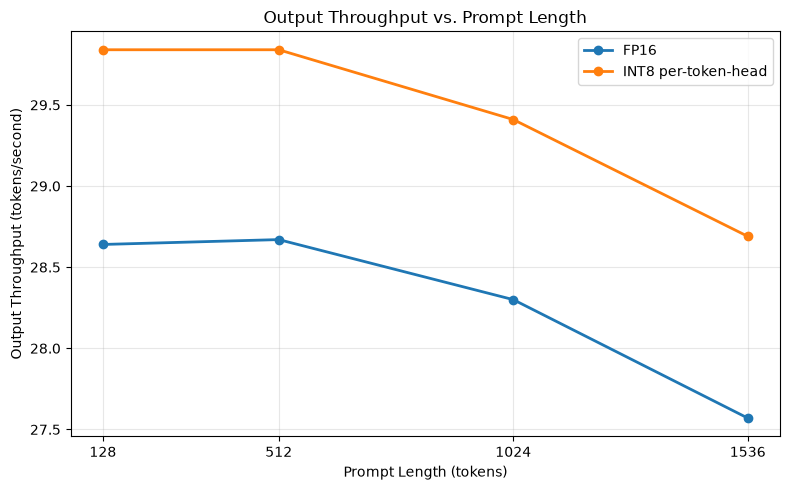

Figure saved to: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/prompt_length_throughput.png


In [8]:
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))

for format_name, group in prompt_lengths_df.groupby("format"):
    group = group.sort_values("prompt_tokens")

    ax.plot(
        group["prompt_tokens"],
        group["output_tokens_per_second"],
        marker="o",
        linewidth=2,
        label=format_name,
    )

ax.set_title("Output Throughput vs. Prompt Length")
ax.set_xlabel("Prompt Length (tokens)")
ax.set_ylabel("Output Throughput (tokens/second)")
ax.set_xticks(sorted(prompt_lengths_df["prompt_tokens"].unique()))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

figure_path = FIGURES_DIR / "prompt_length_throughput.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### Generation Time by Prompt Length

Comparison of total generation time for FP16 and INT8 KV cache formats.

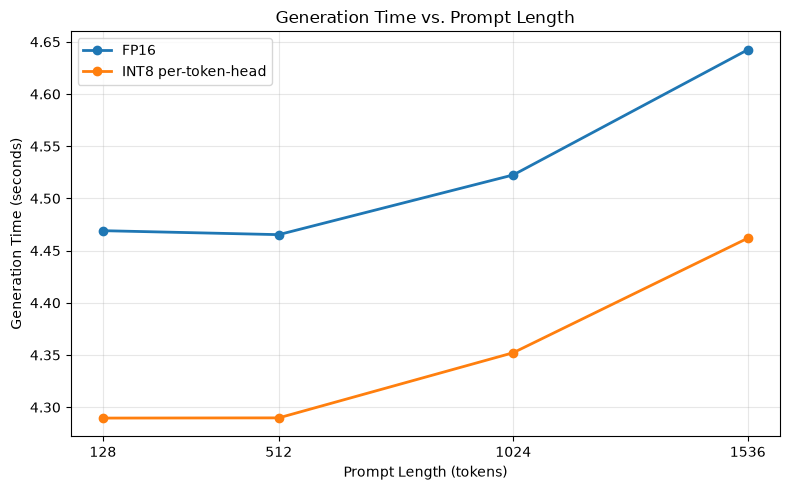

Figure saved to: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/prompt_length_generation_time.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

for format_name, group in prompt_lengths_df.groupby("format"):
    group = group.sort_values("prompt_tokens")

    ax.plot(
        group["prompt_tokens"],
        group["generation_time_seconds"],
        marker="o",
        linewidth=2,
        label=format_name,
    )

ax.set_title("Generation Time vs. Prompt Length")
ax.set_xlabel("Prompt Length (tokens)")
ax.set_ylabel("Generation Time (seconds)")
ax.set_xticks(sorted(prompt_lengths_df["prompt_tokens"].unique()))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

figure_path = FIGURES_DIR / "prompt_length_generation_time.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### Prompt Length Results

INT8 per-token-head consistently achieved higher output throughput and lower
generation time than FP16 across all tested prompt lengths.

The improvement remained relatively stable as the prompt length increased from
128 to 1536 tokens. On average, INT8 improved throughput and generation time by
approximately 4%.

Both formats experienced a gradual performance reduction for longer prompts,
because the attention operation must access a larger KV cache during decoding.

## Concurrency Experiment

This experiment evaluates FP16 and INT8 KV cache performance as the number of
concurrent requests increases.

Each request contains 1024 input tokens and generates 128 output tokens.

In [10]:
auto_concurrency_files = [
    CONCURRENCY_DIR / "auto_concurrency.csv",
    CONCURRENCY_DIR / "auto_concurrency_high.csv",
    CONCURRENCY_DIR / "auto_concurrency_stress.csv",
]

int8_concurrency_files = [
    CONCURRENCY_DIR / "int8_concurrency.csv",
    CONCURRENCY_DIR / "int8_concurrency_high.csv",
    CONCURRENCY_DIR / "int8_concurrency_stress.csv",
]


auto_concurrency = pd.concat(
    [pd.read_csv(path) for path in auto_concurrency_files],
    ignore_index=True,
)

int8_concurrency = pd.concat(
    [pd.read_csv(path) for path in int8_concurrency_files],
    ignore_index=True,
)


auto_concurrency["format"] = "FP16"
int8_concurrency["format"] = "INT8 per-token-head"

concurrency_df = pd.concat(
    [
        auto_concurrency,
        int8_concurrency,
    ],
    ignore_index=True,
)

concurrency_df = concurrency_df.sort_values(
    ["concurrent_requests", "format"]
).reset_index(drop=True)

display(concurrency_df)

,kv_cache_dtype,concurrent_requests,prompt_tokens_per_request,total_input_tokens,total_output_tokens,batch_completion_time_seconds,requests_per_second,output_tokens_per_second,total_tokens_per_second,format
0,auto,1,1024,1024,128,4.4761,0.2230,28.6000,257.3600,FP16
1,int8_per_token_head,1,1024,1024,128,4.3509,0.2300,29.4200,264.7700,INT8 per-token-head
2,auto,4,1024,4096,512,4.9102,0.8150,104.2700,938.4600,FP16
3,int8_per_token_head,4,1024,4096,512,4.8458,0.8250,105.6600,950.9400,INT8 per-token-head
4,auto,8,1024,8192,1024,5.2627,1.5200,194.5800,1751.1900,FP16
5,int8_per_token_head,8,1024,8192,1024,5.1788,1.5450,197.7300,1779.5700,INT8 per-token-head
6,auto,16,1024,16384,2048,6.0879,2.6280,336.4000,3027.6300,FP16
7,int8_per_token_head,16,1024,16384,2048,6.0012,2.6660,341.2600,3071.3600,INT8 per-token-head
8,auto,24,1024,24576,3072,7.0069,3.4250,438.4300,3945.8500,FP16
9,int8_per_token_head,24,1024,24576,3072,7.0638,3.3980,434.9000,3914.0600,INT8 per-token-head


### FP16 vs. INT8 Concurrency Comparison

In [12]:
fp16_concurrency = auto_concurrency[
    [
        "concurrent_requests",
        "batch_completion_time_seconds",
        "requests_per_second",
        "output_tokens_per_second",
        "total_tokens_per_second",
    ]
].rename(
    columns={
        "batch_completion_time_seconds": "fp16_batch_time_seconds",
        "requests_per_second": "fp16_requests_per_second",
        "output_tokens_per_second": "fp16_output_tokens_per_second",
        "total_tokens_per_second": "fp16_total_tokens_per_second",
    }
)

int8_concurrency_compare = int8_concurrency[
    [
        "concurrent_requests",
        "batch_completion_time_seconds",
        "requests_per_second",
        "output_tokens_per_second",
        "total_tokens_per_second",
    ]
].rename(
    columns={
        "batch_completion_time_seconds": "int8_batch_time_seconds",
        "requests_per_second": "int8_requests_per_second",
        "output_tokens_per_second": "int8_output_tokens_per_second",
        "total_tokens_per_second": "int8_total_tokens_per_second",
    }
)

concurrency_comparison_df = fp16_concurrency.merge(
    int8_concurrency_compare,
    on="concurrent_requests",
)

concurrency_comparison_df["batch_time_improvement_percent"] = (
    (
        concurrency_comparison_df["fp16_batch_time_seconds"]
        - concurrency_comparison_df["int8_batch_time_seconds"]
    )
    / concurrency_comparison_df["fp16_batch_time_seconds"]
    * 100
)

concurrency_comparison_df["throughput_improvement_percent"] = (
    (
        concurrency_comparison_df["int8_output_tokens_per_second"]
        - concurrency_comparison_df["fp16_output_tokens_per_second"]
    )
    / concurrency_comparison_df["fp16_output_tokens_per_second"]
    * 100
)

display(concurrency_comparison_df.round(3))

,concurrent_requests,fp16_batch_time_seconds,fp16_requests_per_second,fp16_output_tokens_per_second,fp16_total_tokens_per_second,int8_batch_time_seconds,int8_requests_per_second,int8_output_tokens_per_second,int8_total_tokens_per_second,batch_time_improvement_percent,throughput_improvement_percent
0,1,4.4760,0.2230,28.6000,257.3600,4.3510,0.2300,29.4200,264.7700,2.7970,2.8670
1,4,4.9100,0.8150,104.2700,938.4600,4.8460,0.8250,105.6600,950.9400,1.3120,1.3330
2,8,5.2630,1.5200,194.5800,1751.1900,5.1790,1.5450,197.7300,1779.5700,1.5940,1.6190
3,16,6.0880,2.6280,336.4000,3027.6300,6.0010,2.6660,341.2600,3071.3600,1.4240,1.4450
4,24,7.0070,3.4250,438.4300,3945.8500,7.0640,3.3980,434.9000,3914.0600,-0.8120,-0.8050
5,32,9.2440,3.4620,443.1100,3987.9700,9.3900,3.4080,436.2100,3925.8900,-1.5820,-1.5570
6,40,14.9550,2.6750,342.3600,3081.2500,11.4940,3.4800,445.4400,4008.9600,23.1410,30.1090
7,48,15.9560,3.0080,385.0500,3465.4300,13.8560,3.4640,443.4300,3990.8900,13.1660,15.1620
8,56,17.1380,3.2680,418.2500,3764.2800,16.2680,3.4420,440.6100,3965.5000,5.0740,5.3460
9,64,19.4170,3.2960,421.9000,3797.1100,19.8320,3.2270,413.0700,3717.6600,-2.1370,-2.0930


### Output Throughput by Concurrent Requests

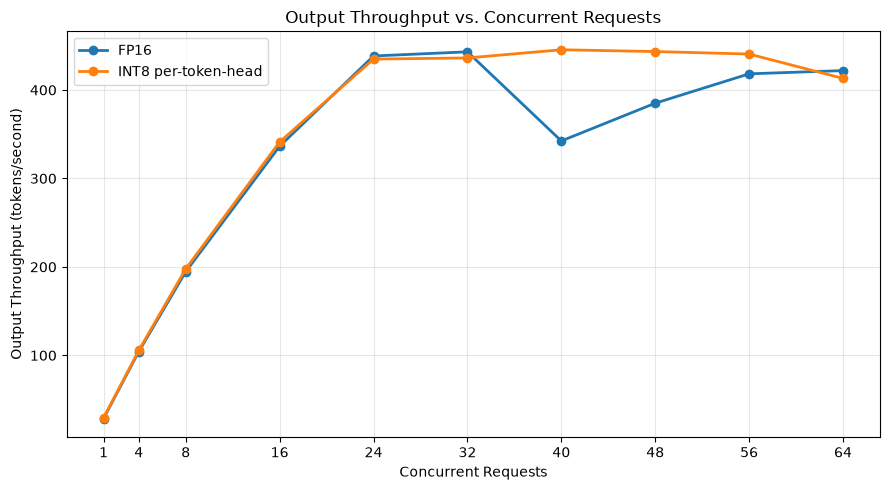

Figure saved to: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/concurrency_output_throughput.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

for format_name, group in concurrency_df.groupby("format"):
    group = group.sort_values("concurrent_requests")

    ax.plot(
        group["concurrent_requests"],
        group["output_tokens_per_second"],
        marker="o",
        linewidth=2,
        label=format_name,
    )

ax.set_title("Output Throughput vs. Concurrent Requests")
ax.set_xlabel("Concurrent Requests")
ax.set_ylabel("Output Throughput (tokens/second)")
ax.set_xticks(
    sorted(concurrency_df["concurrent_requests"].unique())
)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

figure_path = FIGURES_DIR / "concurrency_output_throughput.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### Batch Completion Time by Concurrent Requests

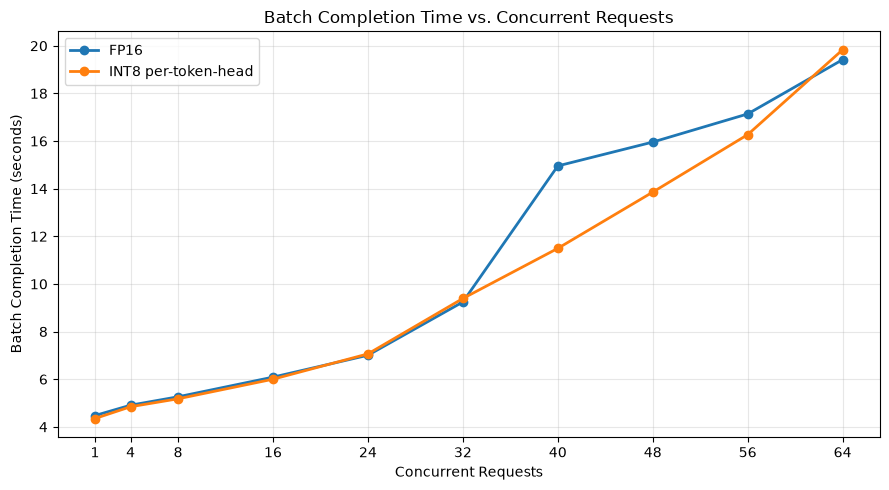

Figure saved to: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/concurrency_batch_completion_time.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for format_name, group in concurrency_df.groupby("format"):
    group = group.sort_values("concurrent_requests")

    ax.plot(
        group["concurrent_requests"],
        group["batch_completion_time_seconds"],
        marker="o",
        linewidth=2,
        label=format_name,
    )

ax.set_title("Batch Completion Time vs. Concurrent Requests")
ax.set_xlabel("Concurrent Requests")
ax.set_ylabel("Batch Completion Time (seconds)")
ax.set_xticks(
    sorted(concurrency_df["concurrent_requests"].unique())
)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

figure_path = FIGURES_DIR / "concurrency_batch_completion_time.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### INT8 Throughput Improvement over FP16

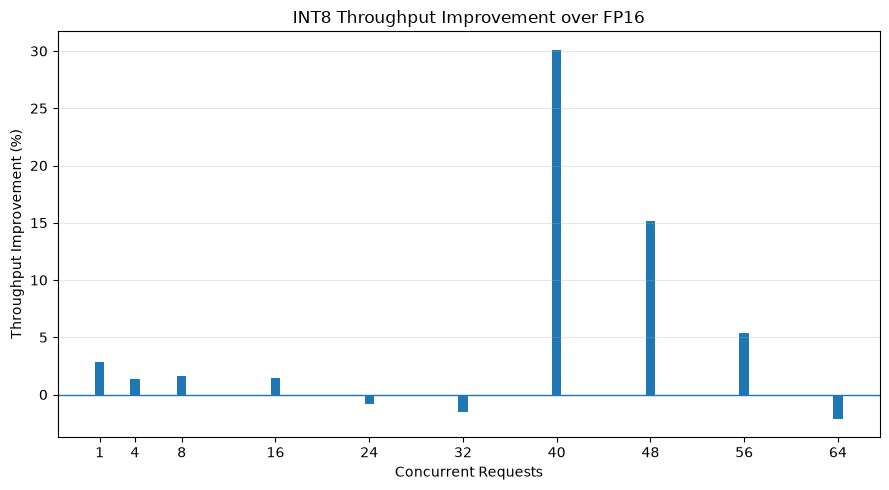

Figure saved to: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/concurrency_int8_improvement.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    concurrency_comparison_df["concurrent_requests"],
    concurrency_comparison_df[
        "throughput_improvement_percent"
    ],
)

ax.axhline(0, linewidth=1)

ax.set_title("INT8 Throughput Improvement over FP16")
ax.set_xlabel("Concurrent Requests")
ax.set_ylabel("Throughput Improvement (%)")
ax.set_xticks(
    concurrency_comparison_df["concurrent_requests"]
)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

figure_path = FIGURES_DIR / "concurrency_int8_improvement.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### Concurrency Experiment Conclusions

At low and moderate concurrency levels, FP16 and INT8 per-token-head provide
similar performance.

The main benefit of INT8 appears when the system experiences high KV-cache
pressure. At 40 concurrent requests, INT8 improves output throughput by
approximately 30% and reduces batch completion time by approximately 23%.

The INT8 advantage remains visible at 48 and 56 concurrent requests, although
the improvement gradually decreases.

At 64 concurrent requests, INT8 throughput becomes slightly lower than FP16.
This result is consistent with INT8 also approaching its KV-cache capacity
limit.

Overall, INT8 does not provide a large speedup for small workloads. Its main
advantage is the larger KV-cache capacity, which delays the performance
degradation caused by high concurrency.

## KV Cache Capacity Summary

The following values were reported by vLLM during engine initialization.

In [16]:
kv_capacity_df = pd.DataFrame(
    {
        "KV cache format": [
            "FP16",
            "INT8 per-token-head",
        ],
        "KV cache memory (GiB)": [
            3.96,
            3.96,
        ],
        "KV cache capacity (tokens)": [
            37056,
            71872,
        ],
        "Maximum concurrency at 2048 tokens": [
            18.09,
            35.09,
        ],
    }
)

kv_capacity_df["Capacity relative to FP16"] = (
    kv_capacity_df["KV cache capacity (tokens)"]
    / kv_capacity_df.loc[
        kv_capacity_df["KV cache format"] == "FP16",
        "KV cache capacity (tokens)",
    ].iloc[0]
)

display(kv_capacity_df.round(2))

,KV cache format,KV cache memory (GiB),KV cache capacity (tokens),Maximum concurrency at 2048 tokens,Capacity relative to FP16
0,FP16,3.9600,37056,18.0900,1.0000
1,INT8 per-token-head,3.9600,71872,35.0900,1.9400


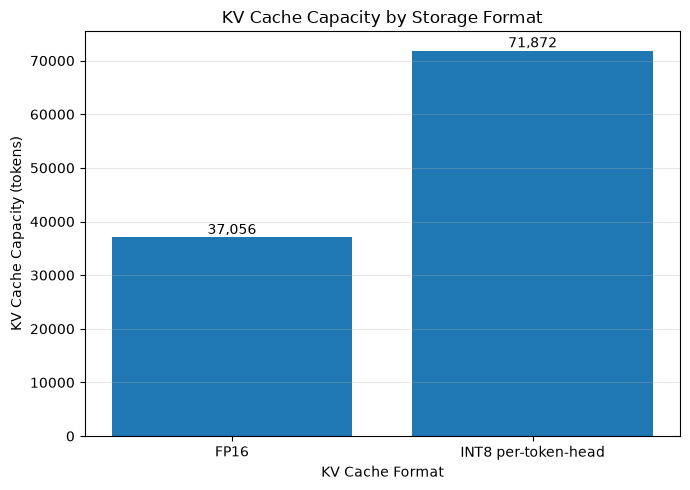

Figure saved to: /home/shani.dayan/kv_cache_project/experiments/results/original_vllm/figures/kv_cache_capacity.png


In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    kv_capacity_df["KV cache format"],
    kv_capacity_df["KV cache capacity (tokens)"],
)

ax.set_title("KV Cache Capacity by Storage Format")
ax.set_xlabel("KV Cache Format")
ax.set_ylabel("KV Cache Capacity (tokens)")
ax.grid(True, axis="y", alpha=0.3)

for index, value in enumerate(
    kv_capacity_df["KV cache capacity (tokens)"]
):
    ax.text(
        index,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
    )

fig.tight_layout()

figure_path = FIGURES_DIR / "kv_cache_capacity.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### KV Cache Capacity Observation

With the same amount of allocated GPU memory, the INT8 per-token-head KV cache
stores 71,872 tokens compared with 37,056 tokens for FP16.

This corresponds to approximately 1.94 times the FP16 capacity, or a 94%
increase in the number of tokens that can be stored in the KV cache.

The larger capacity explains why INT8 maintains high throughput at concurrency
levels where FP16 begins to experience significant KV-cache pressure.